# Task 2 investigation: SEM track-band detection

This notebook documents the debugging session behind `detect_track_row_band` in
`src/preprocessing.py`. It walks through two real failure modes found while running
the 53-tile acceptance sweep, and the fix for each, using the actual dataset.

In [ ]:
import sys
from pathlib import Path

# Auto-detect repo root: search upward from cwd for pyproject.toml -- robust to
# whatever directory Jupyter was launched from (local VS Code, remote Linux server, etc.)
def _find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    return p  # fallback: no marker found, use cwd as-is

REPO = _find_repo_root()
sys.path.insert(0, str(REPO / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import preprocessing as p
from nsf_fmrg_data import load_sem_tile, largest_true_run

SEM_DIR = REPO / 'data' / 'raw' / 'sem'
plt.rcParams['figure.dpi'] = 100

## 1. The underlying signal: per-row roughness

Each SEM tile shows a strip of the printed track surrounded by rougher substrate.
`_row_roughness` computes, for every row, the std of adjacent-pixel differences along
that row — low inside the smooth track band, high in the textured substrate.

Track 8, tile 09 is a clean example: one obvious low-roughness plateau.

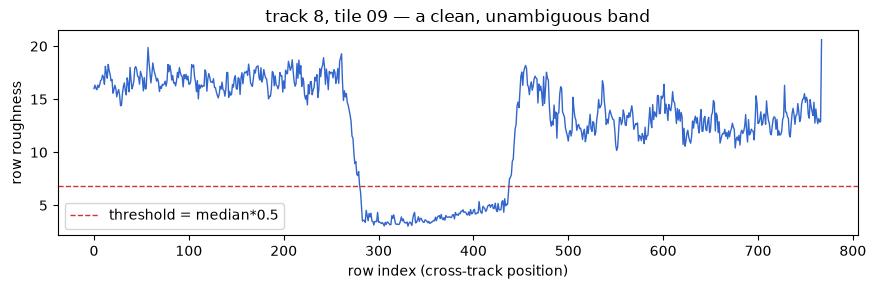

In [ ]:
img = load_sem_tile(p.sem_tile_paths(SEM_DIR, 8)[8])  # tile 09
r = p._row_roughness(img)
thr = np.median(r) * p.SEM_BAND_REL_THRESH

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(r, lw=1, color='#3366cc')
ax.axhline(thr, color='#cc3333', ls='--', lw=1, label=f'threshold = median*{p.SEM_BAND_REL_THRESH}')
ax.set_xlabel('row index (cross-track position)')
ax.set_ylabel('row roughness')
ax.set_title('track 8, tile 09 — a clean, unambiguous band')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Problem A: a real band can fragment into pieces

Track 21, tile 05 sits between tile 04 and tile 06, both of which detect one clean
band around rows 270-342. Tile 05's *true* band is in the same place — but a few rows
inside it have slightly elevated roughness (debris, local imaging noise), which pushes
them just over the threshold. The plain smoothness mask then breaks into several short
runs instead of one long one.

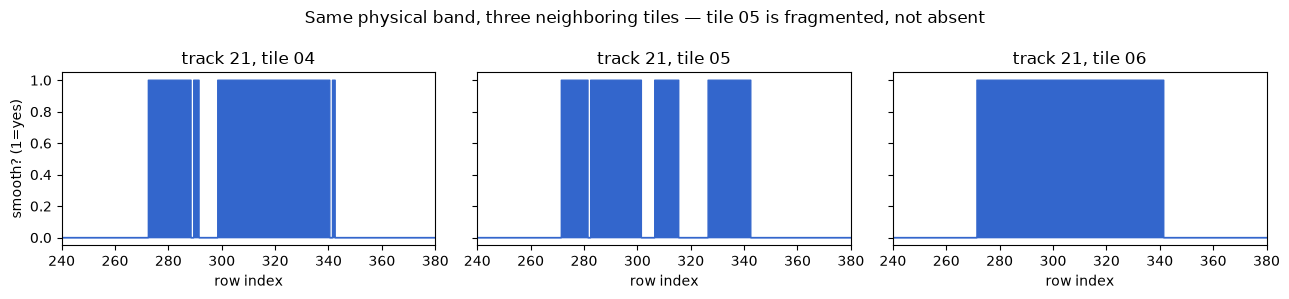

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, tile_idx in zip(axes, [4, 5, 6]):
    img = load_sem_tile(p.sem_tile_paths(SEM_DIR, 21)[tile_idx - 1])
    r = p._row_roughness(img)
    mask = r < (np.median(r) * p.SEM_BAND_REL_THRESH)
    ax.fill_between(np.arange(len(mask)), mask.astype(int), step='mid', color='#3366cc')
    ax.set_title(f'track 21, tile {tile_idx:02d}')
    ax.set_xlim(240, 380)
    ax.set_xlabel('row index')
axes[0].set_ylabel('smooth? (1=yes)')
plt.suptitle('Same physical band, three neighboring tiles — tile 05 is fragmented, not absent')
plt.tight_layout()
plt.show()

Tile 05's mask has four separate smooth runs (roughly rows 272-282, 283-302,
307-316, 327-343) instead of one ~270-343 run like its neighbors. `largest_true_run`
on the raw mask only sees the biggest single piece — the rest gets discarded, and the
detected band comes out far too short (or fails the `min_rows` gate entirely).

In [ ]:
img = load_sem_tile(p.sem_tile_paths(SEM_DIR, 21)[4])  # tile 05
r = p._row_roughness(img)
mask = r < (np.median(r) * p.SEM_BAND_REL_THRESH)
idx = np.flatnonzero(mask)
breaks = np.where(np.diff(idx) > 1)[0]
starts = np.r_[idx[0], idx[breaks + 1]]
stops = np.r_[idx[breaks] + 1, idx[-1] + 1]
runs = list(zip(starts.tolist(), stops.tolist()))
print('track 21 tile 05 raw smooth runs:', runs)
print('largest_true_run on raw mask picks only:', max(runs, key=lambda x: x[1]-x[0]))

track 21 tile 05 raw smooth runs: [(272, 282), (283, 302), (307, 316), (327, 343)]
largest_true_run on raw mask picks only: (283, 302)


### Fix attempt: a sliding-window smooth *density*

Instead of requiring rows to be individually smooth and contiguous, `_smooth_row_density`
computes a moving average of the smoothness mask — the fraction of smooth rows in a
`window`-row neighborhood around each row. A handful of rough rows inside a real band
gets outvoted by their smooth neighbors; genuinely scattered noise never builds up a
comparably high density.

band recovered by density threshold alone: 273..311 (38 rows)
(neighbors 21_04/21_06 detect ~270-342, so this only partially recovers it)


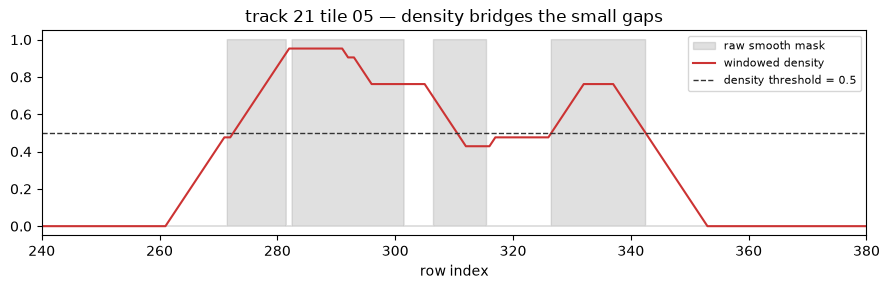

In [ ]:
density = p._smooth_row_density(mask, p.SEM_BAND_DENSITY_WINDOW)

fig, ax = plt.subplots(figsize=(9, 3))
ax.fill_between(np.arange(len(mask)), mask.astype(float), step='mid', alpha=0.3,
                 color='#999999', label='raw smooth mask')
ax.plot(density, color='#cc3333', lw=1.5, label='windowed density')
ax.axhline(p.SEM_BAND_DENSITY_THRESH, color='#333333', ls='--', lw=1,
           label=f'density threshold = {p.SEM_BAND_DENSITY_THRESH}')
ax.set_xlim(240, 380)
ax.set_xlabel('row index')
ax.set_title('track 21 tile 05 — density bridges the small gaps')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

rs, re_ = largest_true_run(density >= p.SEM_BAND_DENSITY_THRESH)
print(f'band recovered by density threshold alone: {rs}..{re_} ({re_-rs} rows)')
print('(neighbors 21_04/21_06 detect ~270-342, so this only partially recovers it)')

## 3. Problem B: the density fix creates a new false positive

Density smoothing fixed tile 05, but re-running the full 53-tile sweep with *only* the
density threshold exposed a new failure: track 10, tile 02 — genuinely a low-contrast
end-tile with no real band — got validated with a spurious ~34-row "band".

Compare its density profile to a real band (track 10, tile 09):

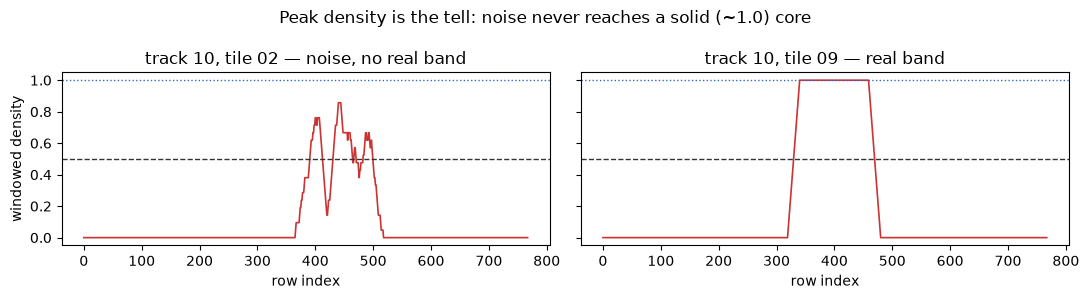

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)

for ax, (track, tile_idx, label) in zip(axes, [(10, 2, 'tile 02 — noise, no real band'),
                                                  (10, 9, 'tile 09 — real band')]):
    img = load_sem_tile(p.sem_tile_paths(SEM_DIR, track)[tile_idx - 1])
    r = p._row_roughness(img)
    mask = r < (np.median(r) * p.SEM_BAND_REL_THRESH)
    density = p._smooth_row_density(mask, p.SEM_BAND_DENSITY_WINDOW)
    ax.plot(density, color='#cc3333', lw=1.2)
    ax.axhline(p.SEM_BAND_DENSITY_THRESH, color='#333333', ls='--', lw=1)
    ax.axhline(1.0, color='#3366cc', ls=':', lw=1)
    ax.set_title(f'track {track}, {label}')
    ax.set_xlabel('row index')
    ax.set_ylim(-0.05, 1.05)
axes[0].set_ylabel('windowed density')
plt.suptitle('Peak density is the tell: noise never reaches a solid (~1.0) core')
plt.tight_layout()
plt.show()

`10_02`'s density peaks at **0.86** and never gets close to 1.0 — it's built from
short, scattered smooth streaks that happen to cluster enough to nudge a 21-row moving
average over 0.5, not a real contiguous band. `10_09`'s density plateaus at a clean
**1.0** for well over 100 rows, because there's an actual unbroken smooth run there.

### The fix: require a solid core, not just a high average

A second gate: the candidate band must contain a peak density of at least
`SEM_BAND_MIN_PEAK_DENSITY`. Checking this against every tile in the dataset shows a
clean separation between genuine bands and noise clusters — worth confirming with data
rather than picking the threshold by eye.

In [ ]:
def raw_max_run(mask):
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return 0
    breaks = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[breaks + 1]]
    stops = np.r_[idx[breaks] + 1, idx[-1] + 1]
    return int((stops - starts).max())

rows = []
for track in [8, 10, 14, 21]:
    paths = p.sem_tile_paths(SEM_DIR, track)
    for i, path in enumerate(paths, start=1):
        img = load_sem_tile(path)
        r = p._row_roughness(img)
        mask = r < (np.median(r) * p.SEM_BAND_REL_THRESH)
        density = p._smooth_row_density(mask, p.SEM_BAND_DENSITY_WINDOW)
        band_mask = density >= p.SEM_BAND_DENSITY_THRESH
        rs, re_ = largest_true_run(band_mask)
        peak = float(density[rs:re_].max()) if rs is not None else 0.0
        height = (re_ - rs) if rs is not None else 0
        rows.append(dict(track=track, tile=i, row_start=rs, row_stop=re_,
                          peak_density=peak, height=height,
                          passes_gate=peak >= p.SEM_BAND_MIN_PEAK_DENSITY and height >= p.SEM_BAND_MIN_ROWS))

df = pd.DataFrame(rows)
df_candidates = df[df.row_start.notna()]  # tiles where a density-threshold band was found at all
df_candidates[['track', 'tile', 'height', 'peak_density', 'passes_gate']].sort_values('peak_density')

,track,tile,height,peak_density,passes_gate
1,8,2,4,0.523810,False
15,10,3,18,0.666667,False
2,8,3,16,0.714286,False
14,10,2,34,0.857143,False
43,21,5,38,0.952381,True
48,21,10,68,1.000000,True
31,14,6,118,1.000000,True
32,14,7,120,1.000000,True
33,14,8,113,1.000000,True
34,14,9,119,1.000000,True


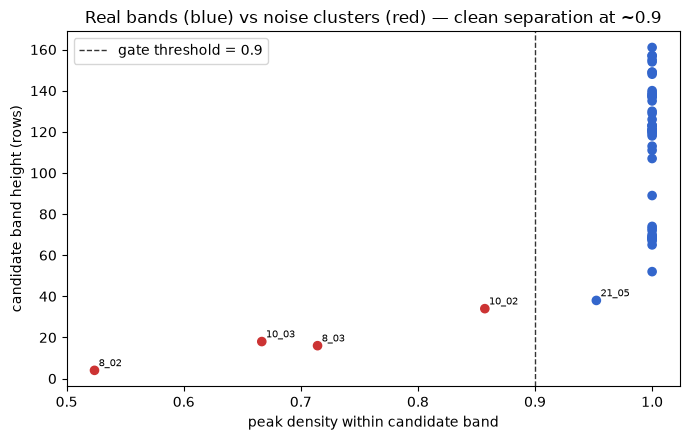

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = df_candidates['passes_gate'].map({True: '#3366cc', False: '#cc3333'})
ax.scatter(df_candidates['peak_density'], df_candidates['height'], c=colors, s=35)
ax.axvline(p.SEM_BAND_MIN_PEAK_DENSITY, color='#333333', ls='--', lw=1,
           label=f'gate threshold = {p.SEM_BAND_MIN_PEAK_DENSITY}')
for _, row in df_candidates.iterrows():
    if row['peak_density'] < 0.97:
        ax.annotate(f"{row.track}_{row.tile:02d}", (row.peak_density, row.height),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('peak density within candidate band')
ax.set_ylabel('candidate band height (rows)')
ax.set_title('Real bands (blue) vs noise clusters (red) — clean separation at ~0.9')
ax.legend()
plt.tight_layout()
plt.show()

The gap is clean: every confirmed real band peaks at density >= 0.952; the highest
noise cluster (`10_02`) tops out at 0.857. `SEM_BAND_MIN_PEAK_DENSITY = 0.9` sits right
in that gap.

## 4. Final sweep: all 53 tiles with both gates active

`detect_track_row_band` now applies three checks in sequence: relative-threshold
smoothness -> windowed-density band -> peak-density solid-core confirmation.

In [ ]:
results = []
for track in [8, 10, 14, 21]:
    paths = p.sem_tile_paths(SEM_DIR, track)
    for i, path in enumerate(paths, start=1):
        img = load_sem_tile(path)
        rs, re_, valid = p.detect_track_row_band(img)
        results.append(dict(track=track, tile=i, valid=valid, row_start=rs, row_stop=re_,
                             height=(re_ - rs) if valid else None))

sweep = pd.DataFrame(results)
n_valid = sweep['valid'].sum()
print(f'{n_valid}/{len(sweep)} valid tiles')
print()
print('invalid tiles:', [(r.track, r.tile) for r in sweep.itertuples() if not r.valid])
print()
print(sweep.groupby('track')['valid'].agg(['sum', 'count']).rename(columns={'sum': 'n_valid', 'count': 'n_total'}))

45/53 valid tiles

invalid tiles: [(8, 1), (8, 2), (8, 3), (10, 1), (10, 2), (10, 3), (14, 1), (21, 1)]

       n_valid  n_total
track                  
8           10       13
10          10       13
14          12       13
21          13       14


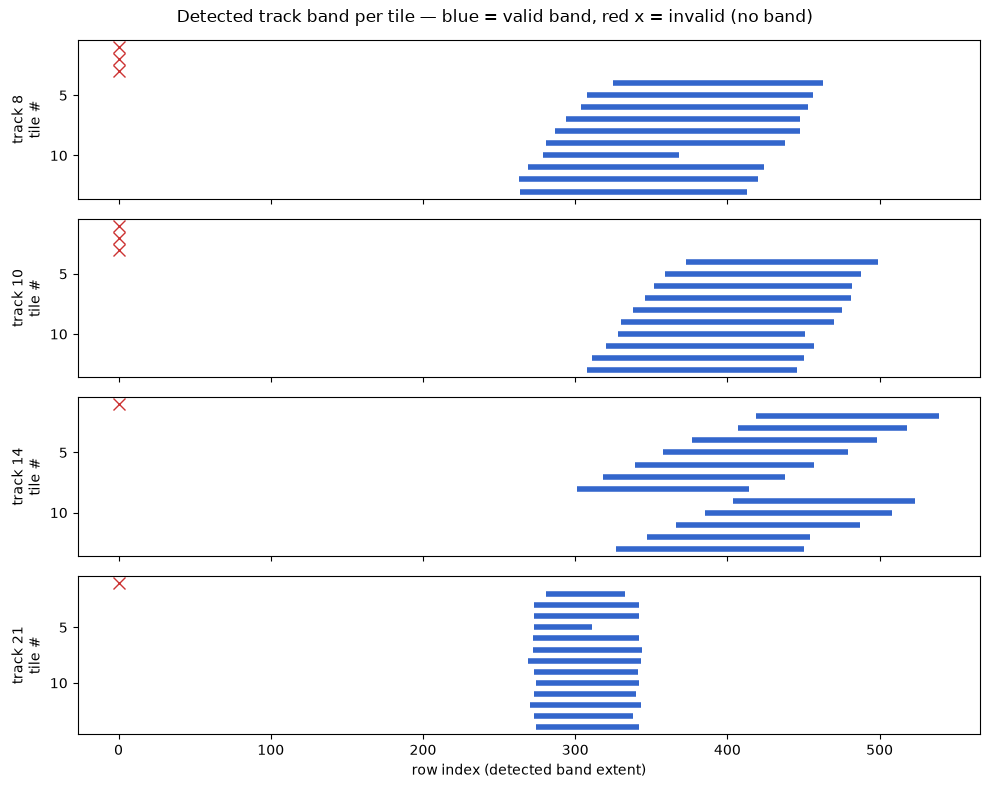

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for ax, track in zip(axes, [8, 10, 14, 21]):
    sub = sweep[sweep.track == track]
    for row in sub.itertuples():
        color = '#3366cc' if row.valid else '#cc3333'
        if row.valid:
            ax.plot([row.row_start, row.row_stop], [row.tile, row.tile], color=color, lw=4, solid_capstyle='butt')
        else:
            ax.plot(0, row.tile, marker='x', color=color, ms=8)
    ax.set_ylabel(f'track {track}\ntile #')
    ax.invert_yaxis()
axes[-1].set_xlabel('row index (detected band extent)')
plt.suptitle('Detected track band per tile — blue = valid band, red x = invalid (no band)')
plt.tight_layout()
plt.show()

## Known residual limitations (not further chased in this session)

- **Tracks 8 and 10 both invalidate 3 tiles at the start (01-03), not just the true
  end-cap (01).** The extra two are correctly rejected by the peak-density gate (their
  best candidates are genuinely noisy, per the diagnostics above) — this looks like a
  real physical effect where contrast dilution near the track's rounded end extends
  further than originally assumed for these two tracks, rather than a detection bug.
  Tracks 14 and 21 only lose their single true end-cap tile.
- **`21_02` (52px) and `21_05` (38px) are valid but shorter than their neighbors
  (~65-74px).** Both have genuine high-confidence solid cores (peak density >= 0.95),
  so they pass the authenticity gate — they're just not fully merged back to their
  neighbors' full extent. A real, milder limitation of the density-window approach,
  not a false positive.
- **Open question, not yet resolved:** Task 1 found track 21's *height-map* track width
  is the widest of the four tracks (~1.30mm mean vs 0.41-0.57mm for tracks 8/10/14),
  but here track 21's SEM band heights are consistently the *smallest* in pixels
  (42-74px vs 91-161px for the other tracks). That's the opposite of what a shared
  physical scale would predict. Worth investigating before trusting SEM-band height as
  a width proxy for track 21 specifically — may be a pixel-size/magnification
  difference between track 21's SEM tiles and the others, not yet checked.